In [10]:
# ── Cell 1 · Install Dependencies ─────────────────────────────────────────
!pip install -q transformers torch datasets scikit-learn pandas numpy matplotlib seaborn tqdm gradio accelerate

In [11]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
from pathlib import Path
from tqdm import tqdm
warnings.filterwarnings('ignore')

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
)

# ─── Paths ────────────────────────────────────────────────────────────────
SARCASM_CSV   = 'train-balanced-sarcasm.csv'
REDDIT_CSV    = 'Reddit_Data.csv'
SARC_CKPT     = './checkpoints/sarcasm'
SENT_CKPT     = './checkpoints/sentiment'
METRICS_FILE  = './checkpoints/metrics.json'
DASHBOARD_PNG = 'performance_summary.png'

# ─── Hyper-parameters ────────────────────────────────────────────────────
BERT_MODEL     = 'bert-base-uncased'
MAX_LEN        = 128
BATCH_SIZE     = 16
EPOCHS         = 3
LR             = 2e-5
SEED           = 42
SARCASM_SAMPLE = 20000   # balanced sample (10k per class); set None to use all ~1M rows

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
np.random.seed(SEED)

for d in [SARC_CKPT, SENT_CKPT]:
    Path(d).mkdir(parents=True, exist_ok=True)

print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

Device  : cpu
PyTorch : 2.11.0+cpu


In [12]:
# ── Cell 3 · Dataset Class & Training Helpers
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.encodings = tokenizer(
            texts, truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt',
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids'      : self.encodings['input_ids'][idx],
            'attention_mask' : self.encodings['attention_mask'][idx],
            'token_type_ids' : self.encodings['token_type_ids'][idx],
            'labels'         : self.labels[idx],
        }


def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc='  train', ncols=80, leave=False):
        optimizer.zero_grad()
        out = model(
            input_ids      = batch['input_ids'].to(DEVICE),
            attention_mask = batch['attention_mask'].to(DEVICE),
            token_type_ids = batch['token_type_ids'].to(DEVICE),
            labels         = batch['labels'].to(DEVICE),
        )
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += out.loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, trues = [], []
    for batch in tqdm(loader, desc='  eval ', ncols=80, leave=False):
        logits = model(
            input_ids      = batch['input_ids'].to(DEVICE),
            attention_mask = batch['attention_mask'].to(DEVICE),
            token_type_ids = batch['token_type_ids'].to(DEVICE),
        ).logits
        preds.extend(logits.argmax(-1).cpu().tolist())
        trues.extend(batch['labels'].tolist())
    return (
        accuracy_score(trues, preds),
        f1_score(trues, preds, average='weighted'),
        trues, preds,
    )


def run_training(model, train_dl, val_dl, ckpt_dir, epochs=EPOCHS):
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    total_steps = len(train_dl) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )
    best_f1, history = 0.0, []
    for epoch in range(1, epochs + 1):
        print(f'\n  Epoch {epoch}/{epochs}')
        loss = train_epoch(model, train_dl, optimizer, scheduler)
        acc, f1, _, _ = evaluate(model, val_dl)
        print(f'    loss={loss:.4f}  val_acc={acc:.4f}  val_f1={f1:.4f}')
        history.append({'epoch': epoch, 'loss': loss, 'val_acc': acc, 'val_f1': f1})
        if f1 > best_f1:
            best_f1 = f1
            model.save_pretrained(ckpt_dir)
            print(f' Best checkpoint saved → {ckpt_dir}')
    return history


print('Helpers ready.')

Helpers ready.


---
##  Model 1 — Sarcasm Detection
**Dataset:** `train-balanced-sarcasm.csv` &nbsp;·&nbsp; **Labels:** `0` Not Sarcastic · `1` Sarcastic

In [13]:
# ── Cell 4 · Load & Preprocess Sarcasm Dataset ────────────────────────────
print('[Sarcasm] Loading …')
df_sarc = pd.read_csv(SARCASM_CSV)[['label', 'comment']].dropna()
df_sarc['comment'] = df_sarc['comment'].astype(str).str.strip()
df_sarc = df_sarc[df_sarc['comment'].str.len() > 5].reset_index(drop=True)
print(f'  Full dataset : {len(df_sarc):,} rows')
print(f'  Label counts :\n{df_sarc["label"].value_counts().to_string()}')

if SARCASM_SAMPLE:
    half = SARCASM_SAMPLE // 2
    df_sarc = pd.concat([
        df_sarc[df_sarc['label']==0].sample(half, random_state=SEED),
        df_sarc[df_sarc['label']==1].sample(half, random_state=SEED),
    ]).sample(frac=1, random_state=SEED).reset_index(drop=True)
    print(f'  Using balanced sample of {len(df_sarc):,} rows')

X_s = df_sarc['comment'].tolist()
y_s = df_sarc['label'].tolist()
X_tr_s, X_tmp_s, y_tr_s, y_tmp_s = train_test_split(X_s, y_s, test_size=0.2, random_state=SEED, stratify=y_s)
X_val_s, X_te_s, y_val_s, y_te_s  = train_test_split(X_tmp_s, y_tmp_s, test_size=0.5, random_state=SEED, stratify=y_tmp_s)
print(f'  Split → train={len(X_tr_s):,}  val={len(X_val_s):,}  test={len(X_te_s):,}')

[Sarcasm] Loading …
  Full dataset : 991,094 rows
  Label counts :
label
1    501640
0    489454
  Using balanced sample of 20,000 rows
  Split → train=16,000  val=2,000  test=2,000


In [14]:
# ── Cell 5 · Tokenise Sarcasm Data ────────────────────────────────────────
print('[Sarcasm] Tokenising …')
tok_sarc = BertTokenizerFast.from_pretrained(BERT_MODEL)

dl_tr_s  = DataLoader(TextDataset(X_tr_s,  y_tr_s,  tok_sarc), batch_size=BATCH_SIZE, shuffle=True)
dl_val_s = DataLoader(TextDataset(X_val_s, y_val_s, tok_sarc), batch_size=BATCH_SIZE)
dl_te_s  = DataLoader(TextDataset(X_te_s,  y_te_s,  tok_sarc), batch_size=BATCH_SIZE)
print('  Done.')

[Sarcasm] Tokenising …
  Done.


In [15]:
# ── Cell 6 · Train or Load Sarcasm Model ──────────────────────────────────
SARC_LABELS = ['Not Sarcastic', 'Sarcastic']

if Path(SARC_CKPT, 'config.json').exists():
    print(f'[Sarcasm]  Checkpoint found — loading from {SARC_CKPT}')
    model_sarc   = BertForSequenceClassification.from_pretrained(SARC_CKPT, num_labels=2).to(DEVICE)
    history_sarc = []
else:
    print('[Sarcasm]  No checkpoint — starting fine-tuning …')
    print('    Tip: reduce SARCASM_SAMPLE in Cell 2 for a faster run.')
    model_sarc = BertForSequenceClassification.from_pretrained(
        BERT_MODEL, num_labels=2,
        id2label={0:'Not Sarcastic',1:'Sarcastic'},
        label2id={'Not Sarcastic':0,'Sarcastic':1},
    ).to(DEVICE)
    history_sarc = run_training(model_sarc, dl_tr_s, dl_val_s, SARC_CKPT)

print('\n[Sarcasm] Test evaluation …')
acc_sarc, f1_sarc, yt_sarc, yp_sarc = evaluate(model_sarc, dl_te_s)
print(f'  Accuracy : {acc_sarc:.4f}')
print(f'  F1 (wtd) : {f1_sarc:.4f}')
print()
print(classification_report(yt_sarc, yp_sarc, target_names=SARC_LABELS))

[Sarcasm]  Checkpoint found — loading from ./checkpoints/sarcasm


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5297.64it/s]


[Sarcasm] Test evaluation …

  Accuracy : 0.7175
  F1 (wtd) : 0.7169

               precision    recall  f1-score   support

Not Sarcastic       0.70      0.76      0.73      1000
    Sarcastic       0.74      0.67      0.70      1000

     accuracy                           0.72      2000
    macro avg       0.72      0.72      0.72      2000
 weighted avg       0.72      0.72      0.72      2000



---
## Model 2 — Reddit Sentiment Analysis
**Dataset:** `Reddit_Data.csv` &nbsp;·&nbsp; **Labels:** `-1` Negative · `0` Neutral · `1` Positive

In [16]:
# ── Cell 7 · Load & Preprocess Reddit Sentiment Data ─────────────────────
print('[Sentiment] Loading …')
df_sent = pd.read_csv(REDDIT_CSV)[['clean_comment','category']].dropna()
df_sent['clean_comment'] = df_sent['clean_comment'].astype(str).str.strip()
df_sent = df_sent[df_sent['clean_comment'].str.len() > 5].reset_index(drop=True)

SENT_LABELS = ['Negative', 'Neutral', 'Positive']
SENT_REMAP  = {-1: 0, 0: 1, 1: 2}        # CrossEntropyLoss needs 0-indexed classes
df_sent['label'] = df_sent['category'].map(SENT_REMAP)
print(f'  Rows: {len(df_sent):,}')
print(f'  Classes:\n{df_sent["label"].value_counts().rename({0:"Negative",1:"Neutral",2:"Positive"}).to_string()}')

X_r = df_sent['clean_comment'].tolist()
y_r = df_sent['label'].tolist()
X_tr_r, X_tmp_r, y_tr_r, y_tmp_r = train_test_split(X_r, y_r, test_size=0.2, random_state=SEED, stratify=y_r)
X_val_r, X_te_r, y_val_r, y_te_r  = train_test_split(X_tmp_r, y_tmp_r, test_size=0.5, random_state=SEED, stratify=y_tmp_r)
print(f'  Split → train={len(X_tr_r):,}  val={len(X_val_r):,}  test={len(X_te_r):,}')

[Sentiment] Loading …
  Rows: 36,555
  Classes:
label
Positive    15759
Neutral     12555
Negative     8241
  Split → train=29,244  val=3,655  test=3,656


In [17]:
# ── Cell 8 · Tokenise Reddit Data ─────────────────────────────────────────
print('[Sentiment] Tokenising …')
tok_sent = BertTokenizerFast.from_pretrained(BERT_MODEL)

dl_tr_r  = DataLoader(TextDataset(X_tr_r,  y_tr_r,  tok_sent), batch_size=BATCH_SIZE, shuffle=True)
dl_val_r = DataLoader(TextDataset(X_val_r, y_val_r, tok_sent), batch_size=BATCH_SIZE)
dl_te_r  = DataLoader(TextDataset(X_te_r,  y_te_r,  tok_sent), batch_size=BATCH_SIZE)
print('  Done.')

[Sentiment] Tokenising …
  Done.


In [18]:
# ── Cell 9 · Train or Load Sentiment Model ────────────────────────────────
if Path(SENT_CKPT, 'config.json').exists():
    print(f'[Sentiment] Checkpoint found — loading from {SENT_CKPT}')
    model_sent   = BertForSequenceClassification.from_pretrained(SENT_CKPT, num_labels=3).to(DEVICE)
    history_sent = []
else:
    print('[Sentiment] ⚠️  No checkpoint — starting fine-tuning …')
    model_sent = BertForSequenceClassification.from_pretrained(
        BERT_MODEL, num_labels=3,
        id2label={0:'Negative',1:'Neutral',2:'Positive'},
        label2id={'Negative':0,'Neutral':1,'Positive':2},
    ).to(DEVICE)
    history_sent = run_training(model_sent, dl_tr_r, dl_val_r, SENT_CKPT)

print('\n[Sentiment] Test evaluation …')
acc_sent, f1_sent, yt_sent, yp_sent = evaluate(model_sent, dl_te_r)
print(f'  Accuracy : {acc_sent:.4f}')
print(f'  F1 (wtd) : {f1_sent:.4f}')
print()
print(classification_report(yt_sent, yp_sent, target_names=SENT_LABELS))

[Sentiment] Checkpoint found — loading from ./checkpoints/sentiment


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 10601.80it/s]



[Sentiment] Test evaluation …


  Accuracy : 0.9382
  F1 (wtd) : 0.9381

              precision    recall  f1-score   support

    Negative       0.91      0.88      0.89       824
     Neutral       0.97      0.96      0.96      1256
    Positive       0.93      0.95      0.94      1576

    accuracy                           0.94      3656
   macro avg       0.94      0.93      0.93      3656
weighted avg       0.94      0.94      0.94      3656



---
## Performance Dashboard

In [19]:
# ── Cell 10 · Save Metrics JSON ───────────────────────────────────────────
metrics = {
    'sarcasm'  : {'accuracy': round(acc_sarc,4), 'f1': round(f1_sarc,4),
                  'y_true': yt_sarc, 'y_pred': yp_sarc,
                  'labels': SARC_LABELS, 'history': history_sarc},
    'sentiment': {'accuracy': round(acc_sent,4), 'f1': round(f1_sent,4),
                  'y_true': yt_sent, 'y_pred': yp_sent,
                  'labels': SENT_LABELS, 'history': history_sent},
}
with open(METRICS_FILE, 'w') as f:
    json.dump(metrics, f)
print(f'Metrics saved → {METRICS_FILE}')

Metrics saved → ./checkpoints/metrics.json


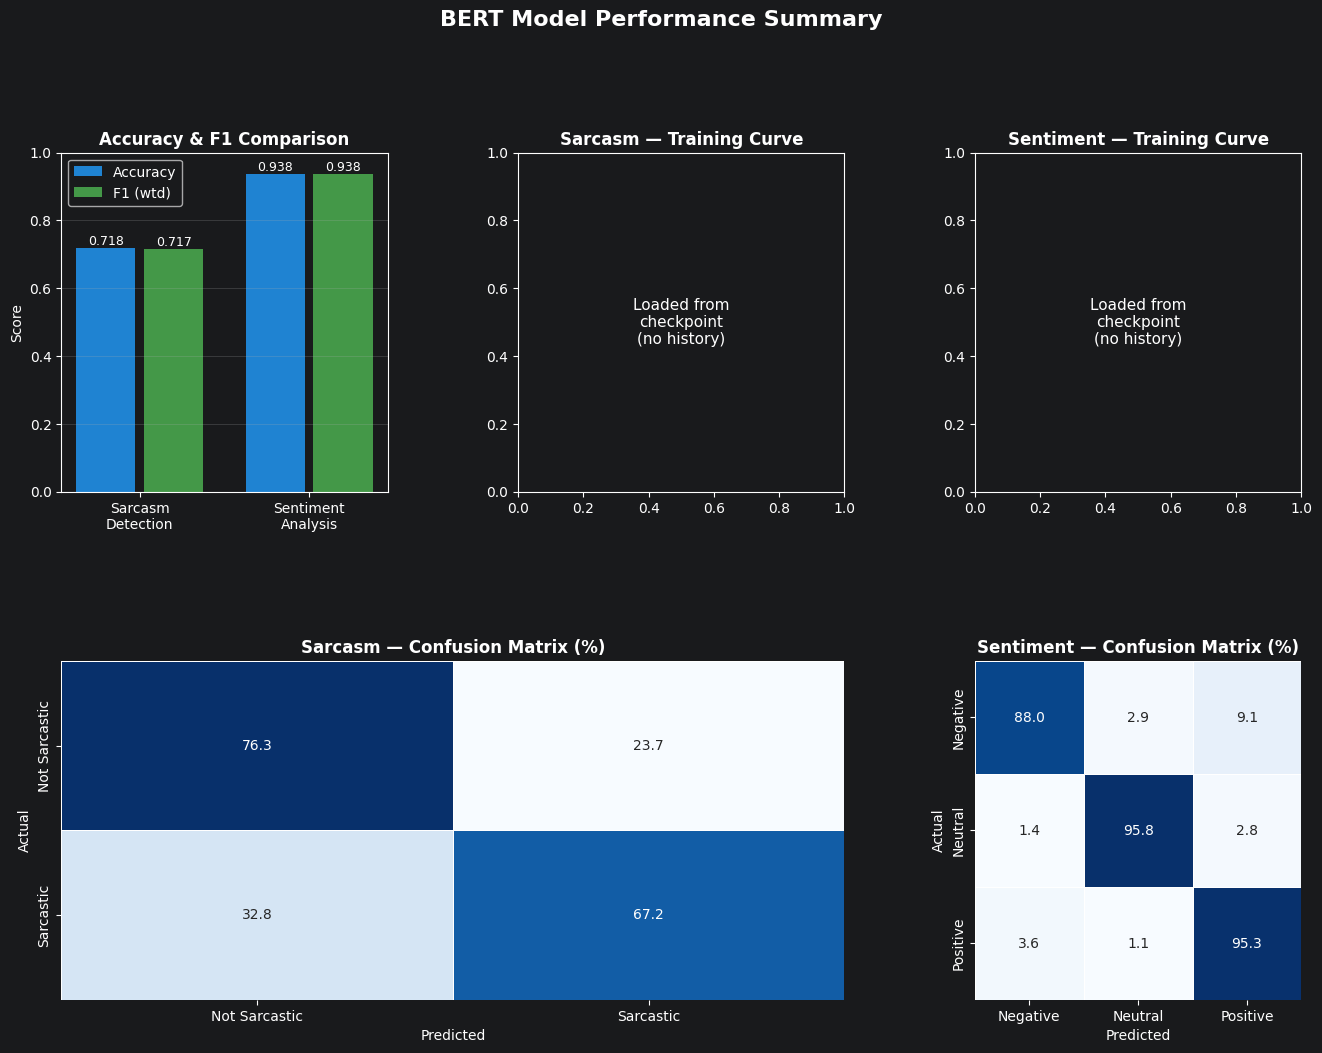

Saved → performance_summary.png


In [20]:
# ── Cell 11 · Performance Dashboard Plot ──────────────────────────────────
def plot_cm(ax, y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')


def plot_curve(ax, history, title):
    if not history:
        ax.text(0.5, 0.5, 'Loaded from\ncheckpoint\n(no history)',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
    else:
        ep = [h['epoch'] for h in history]
        ax.plot(ep, [h['val_acc'] for h in history], 'o-',  label='Val Acc', color='#2196F3')
        ax.plot(ep, [h['val_f1']  for h in history], 's--', label='Val F1',  color='#4CAF50')
        ax.set_ylim(0,1); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
    ax.set_title(title, fontweight='bold')


fig = plt.figure(figsize=(16, 11))
fig.suptitle('BERT Model Performance Summary', fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4)

# Bar chart — Accuracy & F1
ax0 = fig.add_subplot(gs[0, 0])
models_bar = ['Sarcasm\nDetection', 'Sentiment\nAnalysis']
accs = [acc_sarc, acc_sent]; f1s = [f1_sarc, f1_sent]
x = np.arange(2)
ax0.bar(x-0.2, accs, 0.35, label='Accuracy', color='#2196F3', alpha=0.85)
ax0.bar(x+0.2, f1s,  0.35, label='F1 (wtd)', color='#4CAF50', alpha=0.85)
ax0.set_xticks(x); ax0.set_xticklabels(models_bar)
ax0.set_ylim(0,1); ax0.set_ylabel('Score')
ax0.set_title('Accuracy & F1 Comparison', fontweight='bold')
ax0.legend(); ax0.grid(axis='y', alpha=0.3)
for i,(a,f) in enumerate(zip(accs,f1s)):
    ax0.text(i-0.2, a+0.01, f'{a:.3f}', ha='center', fontsize=9)
    ax0.text(i+0.2, f+0.01, f'{f:.3f}', ha='center', fontsize=9)

# Training curves
plot_curve(fig.add_subplot(gs[0,1]), history_sarc, 'Sarcasm — Training Curve')
plot_curve(fig.add_subplot(gs[0,2]), history_sent, 'Sentiment — Training Curve')

# Confusion matrices
plot_cm(fig.add_subplot(gs[1,:2]), yt_sarc, yp_sarc, SARC_LABELS, 'Sarcasm — Confusion Matrix (%)')
plot_cm(fig.add_subplot(gs[1,2]),  yt_sent, yp_sent, SENT_LABELS, 'Sentiment — Confusion Matrix (%)')

plt.savefig(DASHBOARD_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {DASHBOARD_PNG}')

In [21]:
# ── Cell 12 · Tkinter GUI ────────────────────────────────────────────────────
import sys
import json
import tkinter as tk
from tkinter import ttk, scrolledtext
from pathlib import Path
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ─── Lazy model cache ────────────────────────────────────────────────────
_models = {}


def _load(task):
    if task in _models:
        return _models[task]
    ckpt = SARC_CKPT if task == 'sarcasm' else SENT_CKPT
    n_labels = 2 if task == 'sarcasm' else 3
    if not Path(ckpt, 'config.json').exists():
        return None
    m = AutoModelForSequenceClassification.from_pretrained(ckpt, num_labels=n_labels).to(DEVICE).eval()
    t = AutoTokenizer.from_pretrained(BERT_MODEL)
    _models[task] = (m, t)
    return _models[task]


@torch.no_grad()
def _predict(text, task, label_names):
    result = _load(task)
    if result is None:
        cell = 6 if task == 'sarcasm' else 9
        return None, f'Model not trained yet.\nPlease run Cell {cell} first.'
    if not text.strip():
        return None, 'Please enter some text.'
    model, tok = result
    enc = tok(
        text, return_tensors='pt',
        truncation=True, padding=True, max_length=MAX_LEN,
    ).to(DEVICE)
    logits = model(**enc).logits
    probs = F.softmax(logits, dim=-1).squeeze().cpu().tolist()
    if isinstance(probs, float):
        probs = [probs]
    idx = int(logits.argmax(-1).item())
    scores = {label_names[i]: round(probs[i] * 100, 1) for i in range(len(label_names))}
    return label_names[idx], scores


# ─── Reusable confidence bar widget ──────────────────────────────────────────────
class ConfidencePanel(tk.Frame):
    BAR_COLOURS = {
        'Sarcastic': '#E53935',
        'Not Sarcastic': '#43A047',
        'Positive': '#1E88E5',
        'Neutral': '#FB8C00',
        'Negative': '#E53935',
    }

    def __init__(self, parent, label_names, **kwargs):
        super().__init__(parent, bg='#F5F5F5', **kwargs)
        self.label_names = label_names
        self.rows = {}
        for name in label_names:
            row = tk.Frame(self, bg='#F5F5F5')
            row.pack(fill='x', pady=3, padx=8)
            lbl = tk.Label(row, text=name, width=16, anchor='w',
                           font=('Arial', 10), bg='#F5F5F5', fg='#333333')
            lbl.pack(side='left')
            bar = ttk.Progressbar(row, length=260, maximum=100,
                                  mode='determinate',
                                  style=f'{name}.Horizontal.TProgressbar')
            bar.pack(side='left', padx=(4, 8))
            pct = tk.Label(row, text='0.0%', width=6, anchor='e',
                           font=('Arial', 10, 'bold'), bg='#F5F5F5', fg='#555555')
            pct.pack(side='left')
            self.rows[name] = (bar, pct)
            colour = self.BAR_COLOURS.get(name, '#2196F3')
            ttk.Style().configure(f'{name}.Horizontal.TProgressbar',
                                  troughcolor='#E0E0E0', background=colour, thickness=18)

    def update_bars(self, scores):
        for name, (bar, pct) in self.rows.items():
            val = scores.get(name, 0.0)
            bar['value'] = val
            pct.config(text=f'{val:.1f}%')

    def reset(self):
        for bar, pct in self.rows.values():
            bar['value'] = 0
            pct.config(text='0.0%')


# ─── Task tab (shared by Sarcasm and Sentiment) ───────────────────────────────
class TaskTab(tk.Frame):
    EXAMPLES = {
        'sarcasm': [
            'Oh great, another Monday. Just what I needed.',
            'I absolutely love sitting in traffic for two hours.',
            'The weather today is really nice and sunny.',
            'Yeah, because that plan worked SO well last time.',
        ],
        'sentiment': [
            'I really enjoyed reading about Buddhism. Very inspiring.',
            'The policy is neither good nor bad, just neutral.',
            'This is the worst experience I have ever had.',
            'Life is full of ups and downs, nothing special today.',
        ],
    }

    def __init__(self, parent, task, label_names, heading, btn_text, **kwargs):
        super().__init__(parent, bg='#FAFAFA', **kwargs)
        self.task = task
        self.label_names = label_names

        # Heading
        tk.Label(self, text=heading, font=('Arial', 13, 'bold'),
                 bg='#FAFAFA', fg='#1F3864').pack(anchor='w', padx=16, pady=(14, 4))

        # Text input
        tk.Label(self, text='Input Text:', font=('Arial', 10),
                 bg='#FAFAFA', fg='#444444').pack(anchor='w', padx=16)
        self.txt = scrolledtext.ScrolledText(
            self, height=4, width=62, font=('Arial', 11),
            relief='solid', bd=1, wrap='word',
        )
        self.txt.pack(padx=16, pady=(2, 8))

        # Buttons
        btn_frame = tk.Frame(self, bg='#FAFAFA')
        btn_frame.pack(anchor='w', padx=16, pady=(0, 8))
        tk.Button(
            btn_frame, text=btn_text, command=self._run,
            font=('Arial', 11, 'bold'), bg='#2E75B6', fg='white',
            relief='flat', padx=18, pady=6, cursor='hand2',
            activebackground='#1F5496', activeforeground='white',
        ).pack(side='left')
        tk.Button(
            btn_frame, text='Clear', command=self._clear,
            font=('Arial', 11), bg='#E0E0E0', fg='#333333',
            relief='flat', padx=12, pady=6, cursor='hand2',
        ).pack(side='left', padx=(8, 0))

        # Result label
        self.result_var = tk.StringVar(value='—')
        tk.Label(self, textvariable=self.result_var,
                 font=('Arial', 14, 'bold'), bg='#FAFAFA', fg='#1F3864',
                 anchor='w').pack(anchor='w', padx=16, pady=(0, 6))

        # Confidence bars
        tk.Label(self, text='Confidence:', font=('Arial', 10, 'bold'),
                 bg='#FAFAFA', fg='#444444').pack(anchor='w', padx=16)
        self.conf_panel = ConfidencePanel(self, label_names)
        self.conf_panel.pack(anchor='w', padx=8, pady=(2, 12))

        # Quick examples
        tk.Label(self, text='Quick examples:', font=('Arial', 10, 'bold'),
                 bg='#FAFAFA', fg='#444444').pack(anchor='w', padx=16)
        ex_frame = tk.Frame(self, bg='#FAFAFA')
        ex_frame.pack(anchor='w', padx=16, pady=(2, 12))
        for ex in self.EXAMPLES.get(task, []):
            tk.Button(
                ex_frame,
                text=ex[:55] + ('...' if len(ex) > 55 else ''),
                command=lambda e=ex: self._load_example(e),
                font=('Arial', 9), bg='#E8F0FE', fg='#1A237E',
                relief='flat', padx=6, pady=3, cursor='hand2',
                wraplength=420, justify='left',
            ).pack(anchor='w', pady=2)

    def _load_example(self, text):
        self.txt.delete('1.0', 'end')
        self.txt.insert('1.0', text)
        self._run()

    def _run(self):
        text = self.txt.get('1.0', 'end').strip()
        label, result = _predict(text, self.task, self.label_names)
        if label is None:
            self.result_var.set(f'⚠  {result}')
            self.conf_panel.reset()
            return
        emojis = {
            'Sarcastic': '😏',
            'Not Sarcastic': '😊',
            'Positive': '😊',
            'Neutral': '😐',
            'Negative': '😞',
        }
        self.result_var.set(f'{emojis.get(label, "")}  {label}')
        self.conf_panel.update_bars(result)

    def _clear(self):
        self.txt.delete('1.0', 'end')
        self.result_var.set('—')
        self.conf_panel.reset()


# ─── Performance summary tab ───────────────────────────────────────────────────
class PerformanceTab(tk.Frame):
    def __init__(self, parent, **kwargs):
        super().__init__(parent, bg='#FAFAFA', **kwargs)
        tk.Label(self, text='Model Performance Summary',
                 font=('Arial', 13, 'bold'), bg='#FAFAFA', fg='#1F3864',
                 ).pack(anchor='w', padx=16, pady=(14, 8))
        self.text_area = scrolledtext.ScrolledText(
            self, height=18, width=62, font=('Courier', 10),
            state='disabled', relief='solid', bd=1, bg='#F0F4FF',
        )
        self.text_area.pack(padx=16, pady=(0, 10))
        tk.Button(
            self, text='Refresh Metrics', command=self._load,
            font=('Arial', 11, 'bold'), bg='#2E75B6', fg='white',
            relief='flat', padx=14, pady=6, cursor='hand2',
            activebackground='#1F5496', activeforeground='white',
        ).pack(anchor='w', padx=16)
        self._load()

    def _load(self):
        self.text_area.config(state='normal')
        self.text_area.delete('1.0', 'end')
        if not Path(METRICS_FILE).exists():
            self.text_area.insert('end',
                                  '⚠  No metrics found.\n'
                                  'Train both models and run Cell 10 first.')
        else:
            with open(METRICS_FILE) as f:
                m = json.load(f)
            s, r = m['sarcasm'], m['sentiment']
            lines = [
                '=' * 50,
                '  SARCASM DETECTION  (bert-base-uncased, binary)',
                '=' * 50,
                f'  Test Accuracy  :  {s["accuracy"]:.4f}  ({s["accuracy"] * 100:.2f}%)',
                f'  Test F1 (wtd)  :  {s["f1"]:.4f}',
                '',
                '=' * 50,
                '  SENTIMENT ANALYSIS  (bert-base-uncased, 3-class)',
                '=' * 50,
                f'  Test Accuracy  :  {r["accuracy"]:.4f}  ({r["accuracy"] * 100:.2f}%)',
                f'  Test F1 (wtd)  :  {r["f1"]:.4f}',
                '',
                '-' * 50,
                f'  Dashboard PNG  :  {DASHBOARD_PNG}',
                '-' * 50,
            ]
            self.text_area.insert('end', '\n'.join(lines))
        self.text_area.config(state='disabled')


# ─── Main window ────────────────────────────────────────────────────────────────
def launch_gui():
    root = tk.Tk()
    root.title('BERT NLP Classifier')
    root.geometry('600x700')
    root.resizable(True, True)
    root.configure(bg='#FAFAFA')

    # Title header bar
    header = tk.Frame(root, bg='#1F3864', pady=10)
    header.pack(fill='x')
    tk.Label(header, text='BERT NLP Classifier',
             font=('Arial', 16, 'bold'), bg='#1F3864', fg='white').pack()
    tk.Label(header, text='Sarcasm Detection  |  Sentiment Analysis',
             font=('Arial', 10), bg='#1F3864', fg='#A8C4E0').pack()

    # Tab styles
    style = ttk.Style()
    style.theme_use('clam')
    style.configure('TNotebook', background='#FAFAFA', borderwidth=0)
    style.configure('TNotebook.Tab', font=('Arial', 11, 'bold'),
                    padding=[14, 6], background='#E0E0E0', foreground='#333333')
    style.map('TNotebook.Tab',
              background=[('selected', '#2E75B6')],
              foreground=[('selected', 'white')])

    nb = ttk.Notebook(root)
    nb.pack(fill='both', expand=True)

    # Build and add tabs
    sarc_tab = TaskTab(
        nb, task='sarcasm',
        label_names=['Not Sarcastic', 'Sarcastic'],
        heading='Sarcasm Detection',
        btn_text='  Detect  ',
    )
    sent_tab = TaskTab(
        nb, task='sentiment',
        label_names=['Negative', 'Neutral', 'Positive'],
        heading='Sentiment Analysis',
        btn_text='  Analyse  ',
    )
    perf_tab = PerformanceTab(nb)

    nb.add(sarc_tab, text='😏  Sarcasm')
    nb.add(sent_tab, text='💬  Sentiment')
    nb.add(perf_tab, text='📊  Performance')

    # Status bar at bottom
    tk.Label(
        root,
        text=f'Device: {DEVICE}  |  Model: {BERT_MODEL}  |  Python {sys.version.split()[0]}',
        font=('Arial', 8), bg='#E0E0E0', fg='#555555', anchor='w', pady=3,
    ).pack(fill='x', side='bottom')

    root.mainloop()


# ─── Launch ──────────────────────────────────────────────────────────────────────
launch_gui()

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 10355.80it/s]
